✅ 2D Asset güncellendi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\39_bayesian_2d.png
✅ 3D Asset güncellendi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\39_bayesian_3d.png


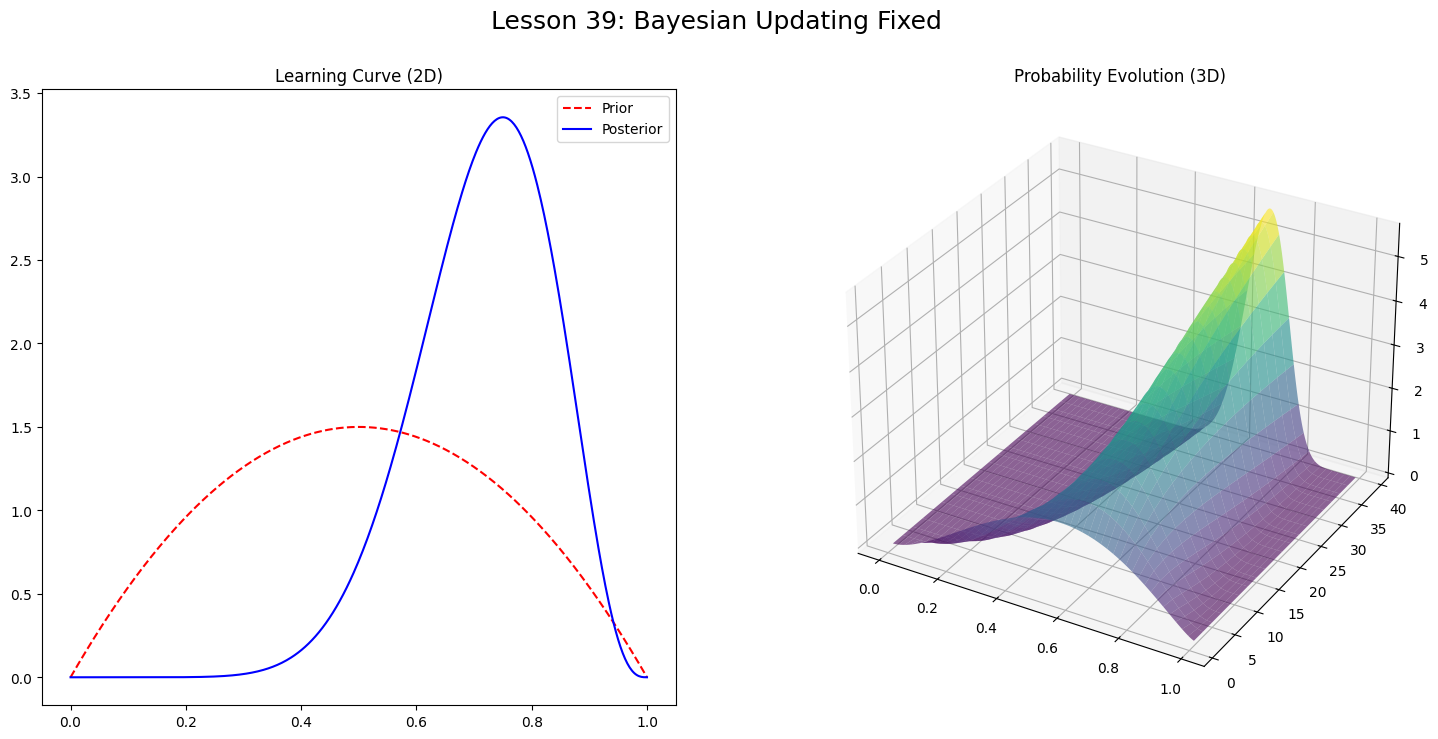

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import os

def run_bayesian_master():
    # --- YOL AYARI ---
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Parametreler (θ: Başarı Olasılığı)
    x = np.linspace(0, 1, 500)
    
    # Prior (Önsel İnanç): Beta(2, 2)
    prior = stats.beta.pdf(x, 2, 2)
    
    # Evidence (Kanıt): 10 denemede 8 başarı
    n, h = 10, 8
    likelihood = stats.binom.pmf(h, n, x)
    
    # FIX: np.trapz yerine np.trapezoid kullanımı (Numpy 2.0+ uyumluluğu)
    area = np.trapezoid(likelihood, x)
    likelihood_norm = likelihood / area 
    
    # Posterior (Güncellenmiş İnanç): Beta(2+h, 2+n-h)
    posterior = stats.beta.pdf(x, 2 + h, 2 + n - h)

    # --- 📸 ASSET 1: 2D (39_bayesian_2d.png) ---
    fig2d, ax2d = plt.subplots(figsize=(10, 7))
    ax2d.plot(x, prior, 'r--', lw=2, label='Prior (Initial Guess)')
    ax2d.plot(x, likelihood_norm, 'g:', lw=2, label='Likelihood (The Evidence)')
    ax2d.plot(x, posterior, 'b-', lw=3, label='Posterior (Updated Belief)')
    ax2d.fill_between(x, 0, posterior, color='blue', alpha=0.2)
    
    ax2d.set_title("2D Bayesian Learning Process", fontsize=14)
    ax2d.set_xlabel("Probability Parameter (θ)")
    ax2d.set_ylabel("Density")
    ax2d.legend()
    
    plt.savefig(os.path.join(asset_path, '39_bayesian_2d.png'), dpi=300)
    print(f"✅ 2D Asset güncellendi: {asset_path}\\39_bayesian_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: 3D (39_bayesian_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    n_steps = np.arange(1, 41, 2) # Daha geniş bir gözlem aralığı
    X_grid, N_grid = np.meshgrid(x, n_steps)
    # Veri biriktikçe (n arttıkça) belirsizliğin nasıl azaldığını simüle edelim
    Z_grid = stats.beta.pdf(X_grid, 2 + 0.7*N_grid, 2 + 0.3*N_grid)

    surf = ax3d.plot_surface(X_grid, N_grid, Z_grid, cmap='viridis', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Bayesian Evolution: Uncertainty Collapse", fontsize=14)
    ax3d.set_xlabel('θ Value'); ax3d.set_ylabel('Sample Size (n)'); ax3d.set_zlabel('Density')
    
    plt.savefig(os.path.join(asset_path, '39_bayesian_3d.png'), dpi=300)
    print(f"✅ 3D Asset güncellendi: {asset_path}\\39_bayesian_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash = plt.figure(figsize=(18, 8))
    ax_l = fig_dash.add_subplot(121)
    ax_l.plot(x, prior, 'r--', label='Prior')
    ax_l.plot(x, posterior, 'b-', label='Posterior')
    ax_l.set_title("Learning Curve (2D)")
    ax_l.legend()

    ax_r = fig_dash.add_subplot(122, projection='3d')
    ax_r.plot_surface(X_grid, N_grid, Z_grid, cmap='viridis', alpha=0.6)
    ax_r.set_title("Probability Evolution (3D)")
    
    plt.suptitle("Lesson 39: Bayesian Updating Fixed", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_bayesian_master()